In [191]:
%pip install numpy pandas matplotlib seaborn scikit-learn scikit-fuzzy datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
import skfuzzy as fuzz

### Loading Dataset

In [193]:
from datasets import load_dataset

# Load the dataset directly from Hugging Face
print("Loading dataset...")
ds = load_dataset("millat/e-commerce-orders")
df = pd.DataFrame(ds['train'])

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Orders: {len(df)}")
print(f"Number of Features: {len(df.columns)}")

Loading dataset...

Dataset Shape: (10000, 15)
Number of Orders: 10000
Number of Features: 15


In [194]:
df.head()

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


In [195]:
print("\nNumerical Features Summary:")
print(df[['price', 'quantity']].describe())


Numerical Features Summary:
              price      quantity
count  10000.000000  10000.000000
mean     252.550681      2.124700
std      141.394146      1.254315
min        5.060000      1.000000
25%      130.607500      1.000000
50%      252.910000      2.000000
75%      374.917500      3.000000
max      499.930000      9.000000


### Feature Engineering

In [196]:
# Calculate total order value
df['total_value'] = df['price'] * df['quantity']
df['order_date'] = pd.to_datetime(df['order_date'])
max_date = df['order_date'].max()

customer_features = df.groupby('customer_id').agg({
    'order_date': lambda x: (max_date - x.max()).days,
    'order_id': 'count',  # Number of orders
    'total_value': ['sum','mean'],  # Spending patterns
}).reset_index()

In [197]:
# Flatten column names
customer_features.columns = ['customer_id', 'recency', 'num_orders',  'total_spending',
                              'avg_order_value']
    
# Fill any remaining NaN
customer_features.fillna(0, inplace=True)

print(f"\nCustomer-level features shape: {customer_features.shape}")
print(f"Number of customers: {len(customer_features)}")
print("\nFeature columns:")
print(customer_features.columns.tolist())


Customer-level features shape: (2713, 5)
Number of customers: 2713

Feature columns:
['customer_id', 'recency', 'num_orders', 'total_spending', 'avg_order_value']


In [198]:
customer_features

,customer_id,recency,num_orders,total_spending,avg_order_value
0,1,0,274,142600.00,520.437956
1,2,10,49,25766.89,525.854898
2,3,0,71,36709.49,517.035070
3,4,10,31,19690.36,635.172903
4,5,4,39,19710.87,505.406923
...,...,...,...,...,...
2708,2995,158,3,1751.77,583.923333
2709,2996,25,2,861.54,430.770000
2710,2997,109,2,506.79,253.395000
2711,2998,169,1,123.94,123.940000


### Data Preparation

In [199]:
# Select features for clustering (exclude customer_id)
feature_cols = [col for col in customer_features.columns if col != 'customer_id']
X = customer_features[feature_cols].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of features used: {len(feature_cols)}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Feature matrix shape: (2713, 4)
Number of features used: 4


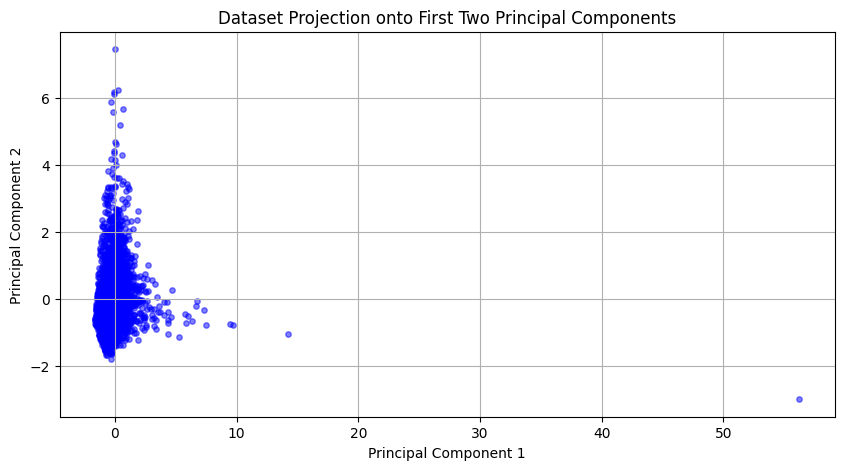

In [200]:
# Reduce Dimensions to 2D (to allow plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# We plot the 2 PCA components, filtering by the cluster label
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=15, c='blue')

plt.grid(True)
plt.title('Dataset Projection onto First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### DETERMINE OPTIMAL NUMBER OF CLUSTERS


Testing cluster numbers from 2 to 7...
k=2: Intertia=8671.860 Silhouette=0.351
k=3: Intertia=5233.826 Silhouette=0.357
k=4: Intertia=3933.600 Silhouette=0.359
k=5: Intertia=3045.412 Silhouette=0.382
k=6: Intertia=2495.820 Silhouette=0.318
k=7: Intertia=2217.516 Silhouette=0.289


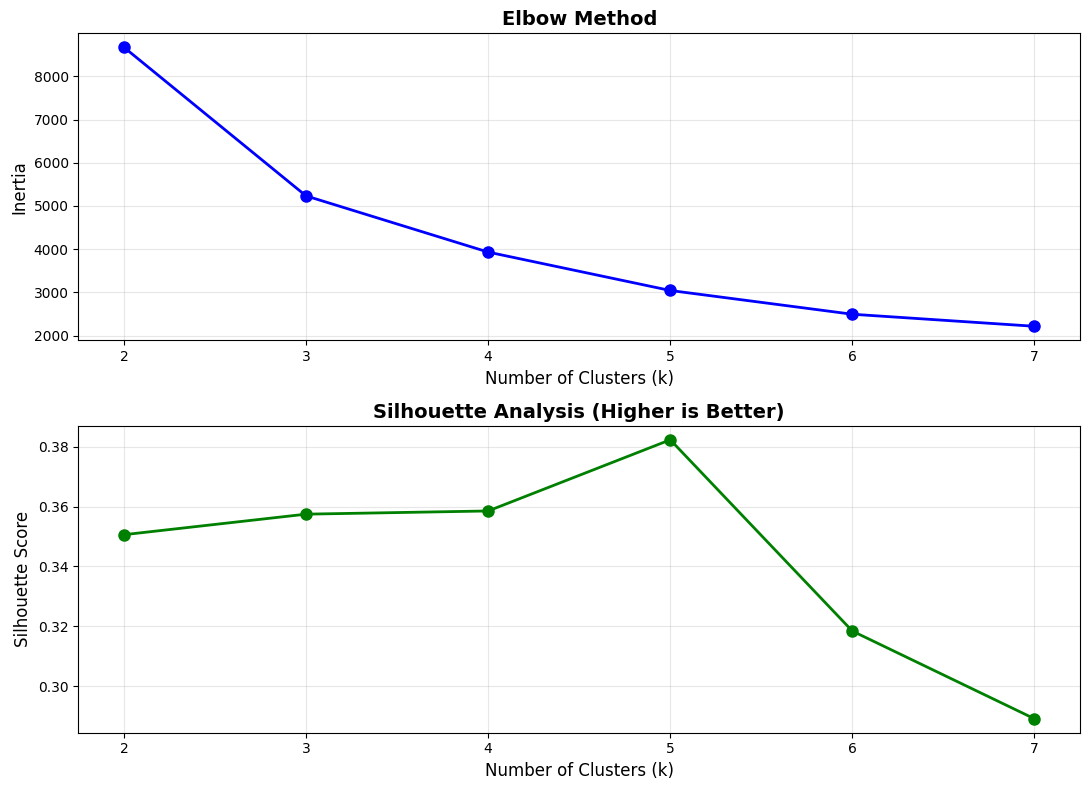

In [ ]:
# Test different numbers of clusters
k_range = range(2, 8)
inertias = []
silhouette_scores = []

print("\nTesting cluster numbers from 2 to 7...")

for k in k_range:
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=32, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    
    print(f"k={k}: Intertia={inertias[-1]:.3f} Silhouette={silhouette_scores[-1]:.3f}")

# Plot elbow curve and metrics
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('charts/cluster_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [202]:
# Select optimal k
optimal_k = 5  # Based on evaluation metrics
print(f"\n✓ Selected optimal number of clusters: {optimal_k}")


✓ Selected optimal number of clusters: 5


### HARD C-MEANS CLUSTERING (K-MEANS)

In [203]:
# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=32, n_init=10)
hard_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
hard_silhouette = silhouette_score(X_scaled, hard_labels)

print(f"\nHard C-Means Results:")
print(f"  Silhouette Score: {hard_silhouette:.4f}")

print("\nCluster Distribution:")
unique, counts = np.unique(hard_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(hard_labels)*100:.1f}%)")



Hard C-Means Results:
  Silhouette Score: 0.3821

Cluster Distribution:
  Cluster 0: 668 customers (24.6%)
  Cluster 1: 1452 customers (53.5%)
  Cluster 2: 1 customers (0.0%)
  Cluster 3: 495 customers (18.2%)
  Cluster 4: 97 customers (3.6%)


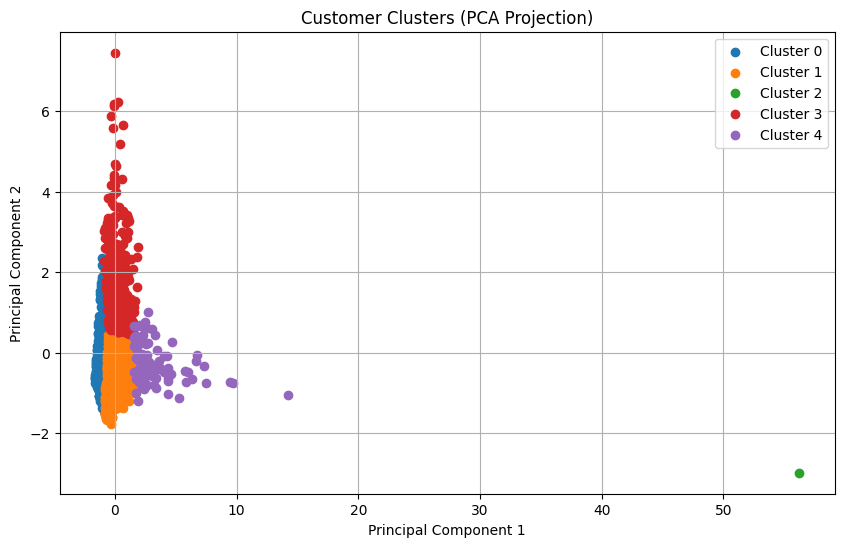

In [204]:
# Reduce Dimensions to 2D (to allow plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# We plot the 2 PCA components, filtering by the cluster label
plt.figure(figsize=(10, 6))

for i in range(0,optimal_k):
    # Scatter plot for Cluster i
    plt.scatter(X_pca[hard_labels == i, 0], X_pca[hard_labels == i, 1], label=f'Cluster {i}')

plt.grid(True)
plt.title('Customer Clusters (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('charts/pca_customer_cluster_hard.png', dpi=300, bbox_inches='tight')
plt.show()

### FUZZY C-MEANS CLUSTERING


Testing cluster numbers from 2 to 7...
k=2: m=1.5 FPC=0.834
k=2: m=2.0 FPC=0.678
k=2: m=2.5 FPC=0.594
k=3: m=1.5 FPC=0.795
k=3: m=2.0 FPC=0.583
k=3: m=2.5 FPC=0.463
k=4: m=1.5 FPC=0.747
k=4: m=2.0 FPC=0.503
k=4: m=2.5 FPC=0.372
k=5: m=1.5 FPC=0.754
k=5: m=2.0 FPC=0.448
k=5: m=2.5 FPC=0.314
k=6: m=1.5 FPC=0.717
k=6: m=2.0 FPC=0.413
k=6: m=2.5 FPC=0.275
k=7: m=1.5 FPC=0.720
k=7: m=2.0 FPC=0.387
k=7: m=2.5 FPC=0.247


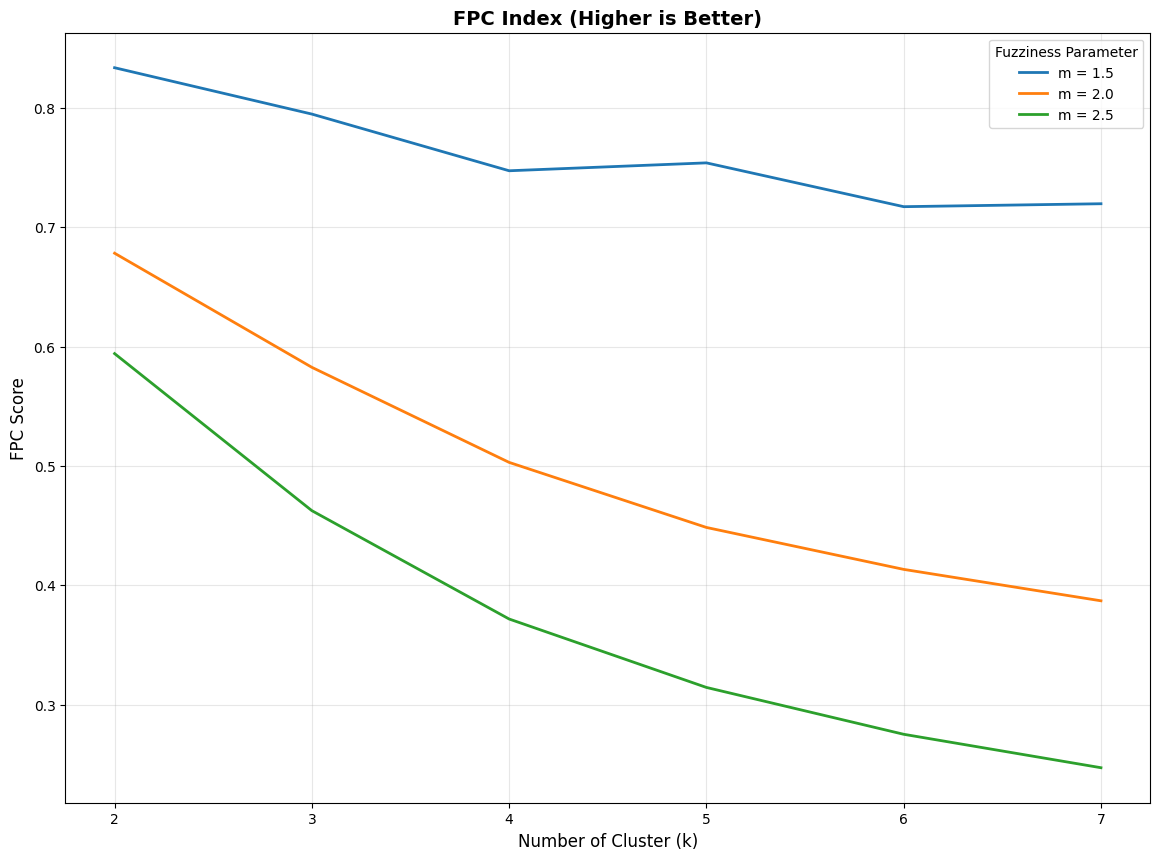

In [205]:
# Test different numbers of clusters
k_range = range(2, 8)
m_range = [1.5, 2.0, 2.5]
inertias = []

fpc_score = {m: [] for m in m_range}
print("\nTesting cluster numbers from 2 to 7...")

for k in k_range:
    for j in m_range:
        # Fit KMeans
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            X_scaled.T, 
            c=k, 
            m=j,  # Fuzziness parameter 
            error=0.005, 
            maxiter=1000, 
            init=None
        )
        fpc_score[j].append(fpc)       
        print(f"k={k}: m={j} FPC={fpc_score[j][-1]:.3f}")

# Plot elbow curve and metrics
fig, axes = plt.subplots(1, 1, figsize=(14, 10))

for i,m in enumerate(m_range):
    axes.plot(k_range, fpc_score[m], linewidth=2, markersize=8, label=f'm = {m}')
    
axes.set_xlabel('Number of Cluster (k)', fontsize=12)
axes.set_ylabel('FPC Score', fontsize=12)
axes.set_title('FPC Index (Higher is Better)', fontsize=14, fontweight='bold')
axes.legend(title="Fuzziness Parameter")
axes.grid(True, alpha=0.3)

plt.savefig('charts/fuzzy_cluster_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [206]:
# Select optimal k
optimal_k = 5  # Based on evaluation metrics
optimal_m = 1.5  # Based on evaluation metrics
print(f"\n✓ Selected optimal number of clusters: {optimal_k}")


✓ Selected optimal number of clusters: 5


In [207]:
# Apply Fuzzy C-Means
# Note: scikit-fuzzy requires transposed data (features x samples)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, 
    c=optimal_k, 
    m=optimal_m,  # Fuzziness parameter (typically between 1.5 and 2.5)
    error=0.005, 
    maxiter=1000, 
    init=None
)

# Get hard labels from fuzzy memberships (for comparison)
fuzzy_hard_labels = np.argmax(u, axis=0)

# Evaluation metrics using hard assignment
fuzzy_silhouette = silhouette_score(X_scaled, fuzzy_hard_labels)

print(f"\nFuzzy C-Means Results:")
print(f"  Silhouette Score: {fuzzy_silhouette:.4f}")
print(f"  Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

print("\nCluster Distribution:")
unique, counts = np.unique(fuzzy_hard_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(fuzzy_hard_labels)*100:.1f}%)")




Fuzzy C-Means Results:
  Silhouette Score: 0.3092
  Fuzzy Partition Coefficient (FPC): 0.7541

Cluster Distribution:
  Cluster 0: 34 customers (1.3%)
  Cluster 1: 578 customers (21.3%)
  Cluster 2: 272 customers (10.0%)
  Cluster 3: 842 customers (31.0%)
  Cluster 4: 987 customers (36.4%)


### COMPARISON OF HARD vs FUZZY CLUSTERING

In [208]:
# Find customers with uncertain memberships
max_memberships = np.max(u, axis=0)
min_memberships = np.min(u, axis=0)
membership_uncertainty = 1 - (max_memberships - min_memberships)

# Categorize customers by certainty
high_certainty = np.sum(max_memberships > 0.8)
medium_certainty = np.sum((max_memberships > 0.5) & (max_memberships <= 0.8))
low_certainty = np.sum(max_memberships <= 0.5)

print(f"\nMembership Certainty Analysis:")
print(f"  High Certainty (>80%): {high_certainty} customers ({high_certainty/len(max_memberships)*100:.1f}%)")
print(f"  Medium Certainty (50-80%): {medium_certainty} customers ({medium_certainty/len(max_memberships)*100:.1f}%)")
print(f"  Low Certainty (<50%): {low_certainty} customers ({low_certainty/len(max_memberships)*100:.1f}%)")

print(f"\n✓ {low_certainty + medium_certainty} customers ({(low_certainty + medium_certainty)/len(max_memberships)*100:.1f}%) "
      f"exhibit overlapping behaviors!")
print("  This is WHY fuzzy clustering is superior for this dataset.")

# Show examples of fuzzy customers
print("\nExample: Customers with Overlapping Memberships")
print("-" * 60)
uncertain_indices = np.where(max_memberships < 0.7)[0][:3]
for idx in uncertain_indices:
    memberships = u[:, idx]
    print(f"\nCustomer {customer_features.iloc[idx]['customer_id']}:")
    for cluster_id in range(optimal_k):
        print(f"  Cluster {cluster_id}: {memberships[cluster_id]:.3f}")


Membership Certainty Analysis:
  High Certainty (>80%): 1756 customers (64.7%)
  Medium Certainty (50-80%): 813 customers (30.0%)
  Low Certainty (<50%): 144 customers (5.3%)

✓ 957 customers (35.3%) exhibit overlapping behaviors!
  This is WHY fuzzy clustering is superior for this dataset.

Example: Customers with Overlapping Memberships
------------------------------------------------------------

Customer 1.0:
  Cluster 0: 0.272
  Cluster 1: 0.177
  Cluster 2: 0.182
  Cluster 3: 0.188
  Cluster 4: 0.181

Customer 3.0:
  Cluster 0: 0.638
  Cluster 1: 0.080
  Cluster 2: 0.088
  Cluster 3: 0.105
  Cluster 4: 0.089

Customer 18.0:
  Cluster 0: 0.371
  Cluster 1: 0.052
  Cluster 2: 0.070
  Cluster 3: 0.354
  Cluster 4: 0.153


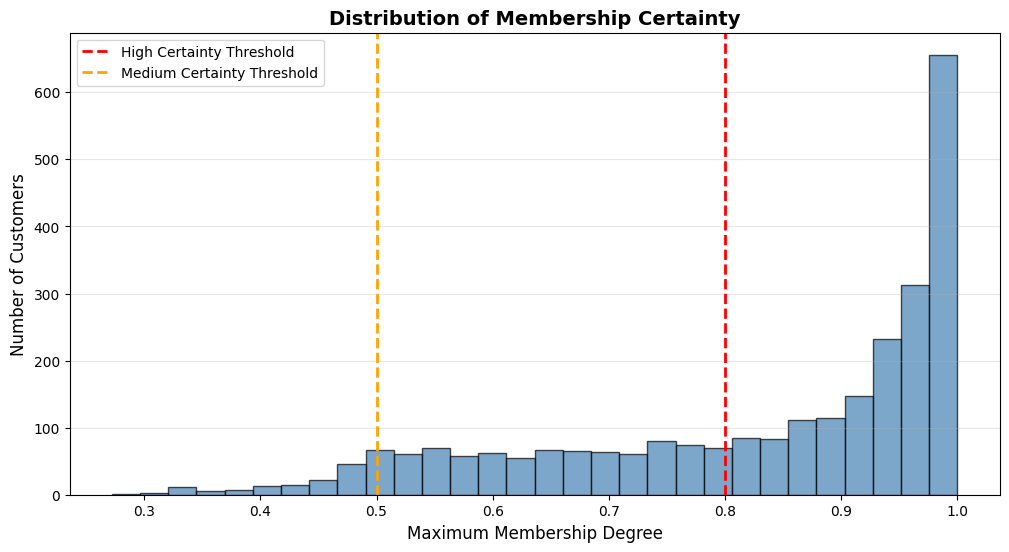

In [209]:
# 3. Membership uncertainty distribution
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(max_memberships, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0.8, color='red', linestyle='--', linewidth=2, label='High Certainty Threshold')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Medium Certainty Threshold')
ax.set_xlabel('Maximum Membership Degree', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Distribution of Membership Certainty', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('charts/distribution_membership.png', dpi=300, bbox_inches='tight')
plt.show()

### BUSINESS INSIGHTS FROM FUZZY CLUSTERING

In [210]:
# Add results to customer features
customer_features['hard_cluster'] = hard_labels
customer_features['fuzzy_cluster'] = fuzzy_hard_labels

# Add membership degrees
for c in range(optimal_k):
    customer_features[f'membership_cluster_{c}'] = u[c]

customer_features['max_membership'] = max_memberships
customer_features['membership_uncertainty'] = membership_uncertainty

# Characterize clusters using original features
print("\nCluster Characterization (using Fuzzy C-Means):")
print("=" * 60)

for cluster_id in range(optimal_k):
    print(f"\nCLUSTER {cluster_id}:")
    print("-" * 60)
    
    # Get customers with high membership to this cluster
    cluster_mask = u[cluster_id] > 0.5
    cluster_data = customer_features[cluster_mask]
    
    print(f"Size: {len(cluster_data)} customers")
    print(f"\nKey Characteristics:")
    print(f"  Avg. Number of Orders: {cluster_data['num_orders'].mean():.2f}")
    print(f"  Avg. Total Spending: ${cluster_data['total_spending'].mean():.2f}")
    print(f"  Avg. Order Value: ${cluster_data['avg_order_value'].mean():.2f}")
    print(f"  Avg. Recency: {cluster_data['recency'].mean():.2f} days")
    # Most common categories
    category_cols = [col for col in cluster_data.columns if col in df['category'].unique()]
    if category_cols:
        top_category = cluster_data[category_cols].sum().idxmax()
        print(f"  Preferred Category: {top_category}")


Cluster Characterization (using Fuzzy C-Means):

CLUSTER 0:
------------------------------------------------------------
Size: 29 customers

Key Characteristics:
  Avg. Number of Orders: 28.14
  Avg. Total Spending: $15047.61
  Avg. Order Value: $539.59
  Avg. Recency: 11.79 days

CLUSTER 1:
------------------------------------------------------------
Size: 540 customers

Key Characteristics:
  Avg. Number of Orders: 1.82
  Avg. Total Spending: $710.80
  Avg. Order Value: $363.35
  Avg. Recency: 240.11 days

CLUSTER 2:
------------------------------------------------------------
Size: 245 customers

Key Characteristics:
  Avg. Number of Orders: 1.93
  Avg. Total Spending: $2280.47
  Avg. Order Value: $1216.09
  Avg. Recency: 154.88 days

CLUSTER 3:
------------------------------------------------------------
Size: 795 customers

Key Characteristics:
  Avg. Number of Orders: 4.90
  Avg. Total Spending: $3104.46
  Avg. Order Value: $667.24
  Avg. Recency: 44.81 days

CLUSTER 4:
--------

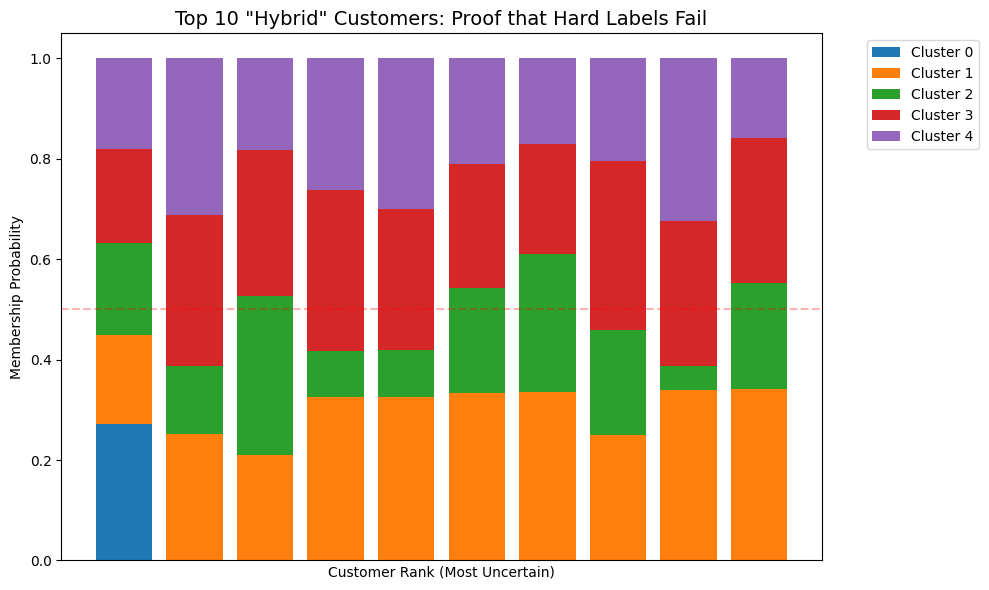

In [211]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the top 10 most "uncertain" customers
# (Those who sit on the fence between clusters)
uncertain_indices = np.argsort(max_memberships)[:10]
uncertain_data = u[:, uncertain_indices]

# 2. Plot their membership breakdown
plt.figure(figsize=(10, 6))
bottom = np.zeros(10)

for cluster_id in range(optimal_k):
    plt.bar(range(10), uncertain_data[cluster_id], bottom=bottom, label=f'Cluster {cluster_id}')
    bottom += uncertain_data[cluster_id]

plt.title('Top 10 "Hybrid" Customers: Proof that Hard Labels Fail', fontsize=14)
plt.ylabel('Membership Probability')
plt.xlabel('Customer Rank (Most Uncertain)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([]) # Hide x-axis numbers for clean look
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Hard Threshold')
plt.tight_layout()
plt.savefig('charts/top10hybrid_customers.png', dpi=300, bbox_inches='tight')
plt.show()